# Training Notebook – Müllerkennung

In diesem Notebook wird **kein neuer Datensatzordner erzeugt**.  
Stattdessen werden die **bereits vorhandenen Daten** aus dem Projekt verwendet:

- `dataset-split/train`
- `dataset-split/val`
- `dataset-split/test`

Optional kann für das Training auch `dataset-augmented/train` verwendet werden.

## Ziel
Trainiert wird ein CNN für die drei Zielklassen:

- `cardboard`
- `glass`
- `plastic`

Die anderen Klassen aus dem ursprünglichen Datensatz (`metal`, `paper`, `trash`) werden **nicht gelöscht** und **nicht kopiert**, sondern beim Laden einfach **ignoriert**.

## Ablauf
1. Projektordner finden  
2. Bereits vorhandene Datensätze prüfen  
3. Nur gewünschte Klassen laden  
4. CNN trainieren  
5. Accuracy und Loss auswerten  
6. Confusion Matrix und Beispielvorhersagen anzeigen  
7. Modell speichern


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Sequential
from sklearn.metrics import classification_report, confusion_matrix


## 1. Projektordner automatisch finden

Hier wird nur sichergestellt, dass das Notebook im richtigen Projektordner arbeitet.  
Es werden dabei **keine Dateien verändert**.


In [2]:
DATASET_DIR = "dataset-split"

def find_project_root(start_path, required_folder=DATASET_DIR):
    current = start_path
    while True:
        if required_folder in os.listdir(current):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            return None
        current = parent

print("Aktueller Arbeitsordner:", os.getcwd())

project_root = find_project_root(os.getcwd())

if project_root is None:
    raise FileNotFoundError(f"'{DATASET_DIR}' konnte nicht gefunden werden.")

if os.getcwd() != project_root:
    os.chdir(project_root)
    print("Arbeitsverzeichnis gesetzt auf:", project_root)
else:
    print("Arbeitsverzeichnis war schon korrekt.")

print("Inhalt des Projektordners:")
print(os.listdir())


Aktueller Arbeitsordner: c:\Users\GOPLP\OneDrive - Bayer\Personal Data\DataLabTrash\src
Arbeitsverzeichnis gesetzt auf: c:\Users\GOPLP\OneDrive - Bayer\Personal Data\DataLabTrash
Inhalt des Projektordners:
['.git', '.venv', 'dataset-224', 'dataset-augmented', 'dataset-original', 'dataset-resized', 'dataset-split', 'output', 'README.md', 'requirements.txt', 'src', 'venv']


## 2. Pfade und Zielklassen festlegen

Hier definieren wir:
- welche Klassen wir wirklich trainieren wollen
- welche vorhandenen Ordner benutzt werden sollen

### Wichtiger Punkt
Für das Training kannst du zwei Varianten nutzen:

- **Variante A:** normales Training mit `dataset-split/train`
- **Variante B:** Training mit augmentierten Bildern aus `dataset-augmented/train`

Unten ist standardmäßig **Variante B** aktiv, weil die augmentierten Trainingsdaten schon vorhanden sind.  
Wenn du lieber ohne Augmentation trainieren willst, ändere einfach `USE_AUGMENTED_TRAIN = False`.


In [3]:
TARGET_CLASSES = ["cardboard", "glass", "plastic"]

USE_AUGMENTED_TRAIN = True

if USE_AUGMENTED_TRAIN:
    train_dir = os.path.join("dataset-augmented", "train")
else:
    train_dir = os.path.join("dataset-split", "train")

val_dir = os.path.join("dataset-split", "val")
test_dir = os.path.join("dataset-split", "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

print("Train-Verzeichnis:", train_dir)
print("Validation-Verzeichnis:", val_dir)
print("Test-Verzeichnis:", test_dir)
print("Zielklassen:", TARGET_CLASSES)


Train-Verzeichnis: dataset-augmented\train
Validation-Verzeichnis: dataset-split\val
Test-Verzeichnis: dataset-split\test
Zielklassen: ['cardboard', 'glass', 'plastic']


## 3. Vorhandene Ordner prüfen

Diese Zelle prüft nur, ob die Verzeichnisse existieren und welche Klassenordner darin liegen.


In [4]:
print("train_dir existiert:", os.path.isdir(train_dir))
print("val_dir existiert:", os.path.isdir(val_dir))
print("test_dir existiert:", os.path.isdir(test_dir))

print("\nKlassen in train_dir:", os.listdir(train_dir))
print("Klassen in val_dir:", os.listdir(val_dir))
print("Klassen in test_dir:", os.listdir(test_dir))


train_dir existiert: True
val_dir existiert: True
test_dir existiert: True

Klassen in train_dir: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Klassen in val_dir: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Klassen in test_dir: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4. Dateiliste nur für die gewünschten Klassen erstellen

`image_dataset_from_directory()` wäre hier unpraktisch, weil in euren bestehenden Ordnern noch zusätzliche Klassen liegen.  
Darum sammeln wir jetzt **nur die Dateien der drei Zielklassen** und bauen daraus TensorFlow-Datasets.

Das hat den Vorteil:
- keine neuen Ordner
- keine zusätzlichen Git-Changes
- volle Kontrolle über die verwendeten Klassen


In [5]:
label_to_index = {label: idx for idx, label in enumerate(TARGET_CLASSES)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

def collect_filepaths(base_dir, class_names):
    filepaths = []
    labels = []

    for cls in class_names:
        cls_dir = os.path.join(base_dir, cls)

        if not os.path.isdir(cls_dir):
            raise FileNotFoundError(f"Klassenordner nicht gefunden: {cls_dir}")

        for file in os.listdir(cls_dir):
            path = os.path.join(cls_dir, file)
            if os.path.isfile(path):
                filepaths.append(path)
                labels.append(label_to_index[cls])

    return pd.DataFrame({
        "filepath": filepaths,
        "label": labels
    })

train_df = collect_filepaths(train_dir, TARGET_CLASSES)
val_df = collect_filepaths(val_dir, TARGET_CLASSES)
test_df = collect_filepaths(test_dir, TARGET_CLASSES)

print("Train:", len(train_df), "Bilder")
print("Val:", len(val_df), "Bilder")
print("Test:", len(test_df), "Bilder")

display(train_df.head())


Train: 2907 Bilder
Val: 207 Bilder
Test: 210 Bilder


,filepath,label
0,dataset-augmented\train\cardboard\cardboard10.jpg,0
1,dataset-augmented\train\cardboard\cardboard100...,0
2,dataset-augmented\train\cardboard\cardboard100...,0
3,dataset-augmented\train\cardboard\cardboard100...,0
4,dataset-augmented\train\cardboard\cardboard102...,0


## 5. Verteilung der Klassen prüfen

So kannst du direkt sehen, wie viele Bilder pro Klasse im Training, in der Validation und im Test vorhanden sind.


In [6]:
def class_counts(df, name):
    counts = df["label"].map(index_to_label).value_counts().sort_index()
    print(f"\n{name}")
    print(counts)

class_counts(train_df, "Train")
class_counts(val_df, "Validation")
class_counts(test_df, "Test")



Train
label
cardboard     846
glass        1050
plastic      1011
Name: count, dtype: int64

Validation
label
cardboard    60
glass        75
plastic      72
Name: count, dtype: int64

Test
label
cardboard    61
glass        76
plastic      73
Name: count, dtype: int64


## 6. TensorFlow-Datasets aus Dateipfaden bauen

Die Bilder werden beim Laden:
- eingelesen
- auf `224x224` gebracht
- als Tensor verwendet

Die Labels bleiben Integer:
- `0 = cardboard`
- `1 = glass`
- `2 = plastic`


In [7]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Datasets erstellt.")


Datasets erstellt.


## 7. Beispielbilder anzeigen

Damit kann geprüft werden, ob die drei Zielklassen korrekt geladen wurden.


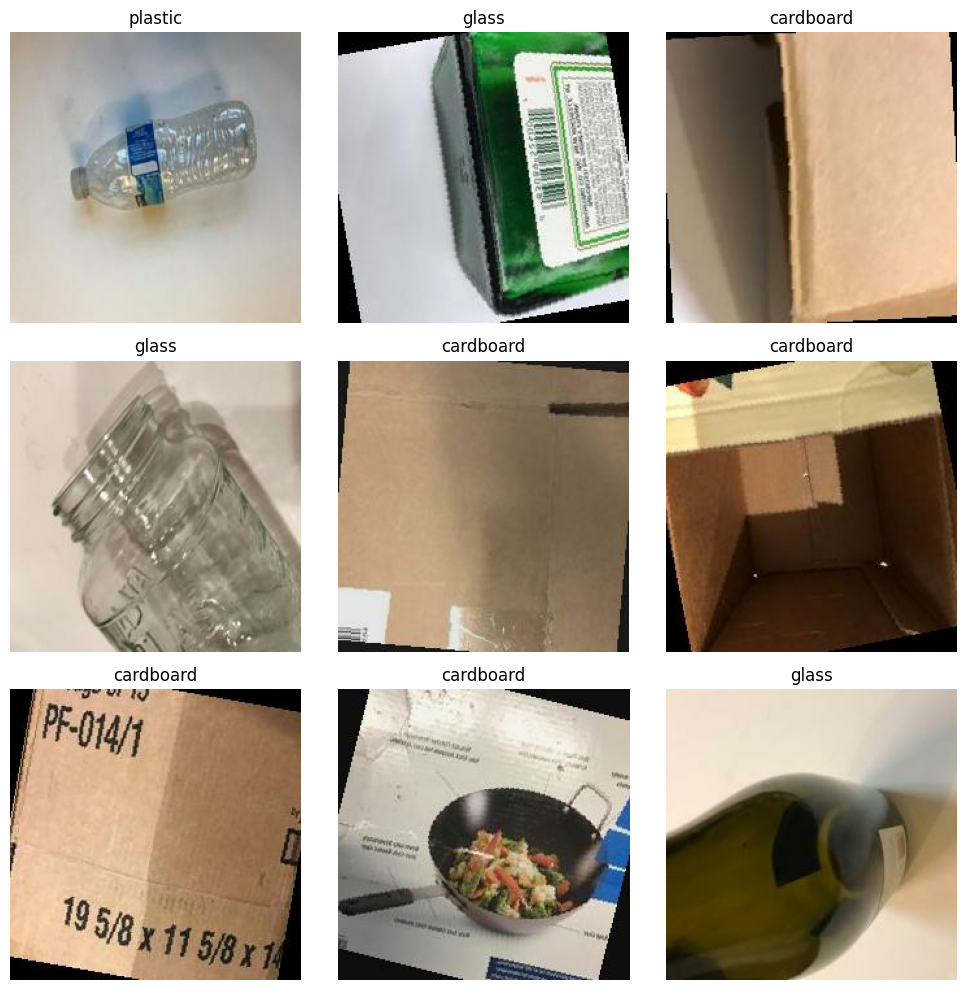

In [8]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        plt.title(index_to_label[int(labels[i].numpy())])
        plt.axis("off")

plt.tight_layout()
plt.show()


## Notwendigen Bibliotheken herunterladen

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import MobileNetV2

## 8. CNN-Modell definieren

Hier wird ein einfaches Convolutional Neural Network gebaut.  
Das reicht für das Projekt und ist gut erklärbar.


In [2]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3,3), padding='same', activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), padding='same', activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), padding='same', activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), padding='same', activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(6, activation="softmax")

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,846 (25.99 MB)

 Trainable params: 6,811,846 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Modell kompilieren

- **Optimizer:** Adam  
- **Loss:** sparse categorical crossentropy  
- **Metrik:** Accuracy


In [3]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,846 (25.99 MB)

 Trainable params: 6,811,846 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

## RestNet80

In [ ]:
base_model = ResNet50(
   weights='imagenet',       # vortrainiert
   include_top=False,        # ohne alten Klassifikationskopf
   input_shape=(224, 224, 3)
)
for layer in base_model.layers:
   layer.trainable = False
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)   # moderner als Flatten
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(6, activation='softmax')(x)
model_resnet = keras.Model(
   inputs=base_model.input,
   outputs=output
)
model_resnet.summary()
model_resnet.compile(
   optimizer='adam',
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy']
)

## MoblieNetV2

In [ ]:
base_model = MobileNetV2(
   weights='imagenet',
   include_top=False,
   input_shape=(224, 224, 3)
)
for layer in base_model.layers:
   layer.trainable = False
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(6, activation='softmax')(x)
model_mobilenet = keras.Model(
   inputs=base_model.input,
   outputs=output
)
model_mobilenet.summary()
model_mobilenet.compile(
   optimizer='adam',
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy']
)

## 10. Modell trainieren

Mit `EarlyStopping` wird verhindert, dass unnötig lange trainiert wird, wenn sich das Modell nicht weiter verbessert.


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)


## 11. Accuracy und Loss visualisieren

Hier sieht man:
- wie gut das Modell auf den Trainingsdaten lernt
- wie gut es auf den Validierungsdaten generalisiert


In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.show()


## 12. Testdaten auswerten

Jetzt wird das trainierte Modell auf den Testdaten bewertet.


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


## 13. Classification Report und Confusion Matrix

Damit kann detaillierter geprüft werden:
- welche Klasse gut erkannt wird
- welche Klassen verwechselt werden


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES))


In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=TARGET_CLASSES, columns=TARGET_CLASSES)

print(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(TARGET_CLASSES))
plt.xticks(tick_marks, TARGET_CLASSES, rotation=45)
plt.yticks(tick_marks, TARGET_CLASSES)

for i in range(len(TARGET_CLASSES)):
    for j in range(len(TARGET_CLASSES)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Tatsächliche Klasse")
plt.xlabel("Vorhergesagte Klasse")
plt.tight_layout()
plt.show()


## 14. Beispielvorhersagen anzeigen

Hier werden ein paar Testbilder zusammen mit
- wahrer Klasse
- vorhergesagter Klasse

angezeigt. Das ist gut für die Präsentation.


In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        true_label = index_to_label[int(labels[i].numpy())]
        pred_label = index_to_label[int(preds[i])]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()


## 15. Modell speichern

Das trainierte Modell wird als `.keras`-Datei gespeichert und kann später für Vorhersagen wiederverwendet werden.


In [ ]:
model.save("trash_classifier_3classes.keras")
print("Modell gespeichert.")
